# Maken generieren

## Brain mask

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_for_mask = np.load('MetabMaps/Lesion_GT/water_amp_Lesion_GT_Orig.npy')[...,-1]

mx = np.nanmax(data_for_mask)              # ignoriert NaNs
threshold = 0.01 * mx
brain_mask = (data_for_mask > threshold).astype(np.uint8)

# optional: NaNs explizit auf 0 setzen
brain_mask[np.isnan(data_for_mask)] = 0

# Lesion mask small

In [2]:
import nibabel as nib
import numpy as np

# NIfTI laden
nii = nib.load("Lesion_lr.nii")

# als NumPy-Array (float64)
Lesion_mask = nii.get_fdata()

Lesion_mask = np.swapaxes(Lesion_mask, -1, 0)

print(Lesion_mask.shape, Lesion_mask.dtype)

(21, 22, 22) float64


# Lac mask

In [3]:
data_for_Les_mask = np.load('MetabMaps/Lesion_GT/Lac_amp_Lesion_GT_Orig.npy')[...,-1]

mx = np.nanmax(data_for_Les_mask)              # ignoriert NaNs
threshold = 0.1 * mx
Lesion_mask = (data_for_Les_mask > threshold).astype(np.uint8)

# optional: NaNs explizit auf 0 setzen
Lesion_mask[np.isnan(data_for_Les_mask)] = 0

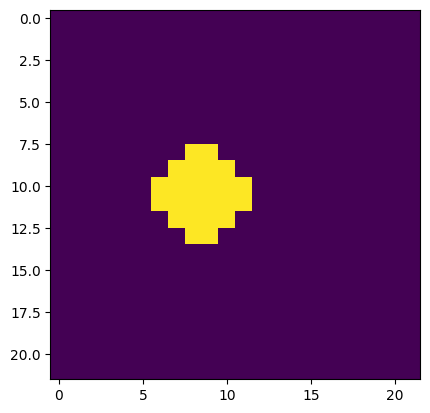

In [4]:
z = 13

plt.imshow(Lesion_mask[z,...])

# Define helper Function for RMSE over time

In [5]:
import os
import numpy as np

def load_metab_map(root, method, metabolite, suffix="Orig"):
    """
    Loads: {root}/{method}/{metabolite}_amp_{method}_{suffix}.npy
    """
    fname = f"{metabolite}_amp_{method}_{suffix}.npy"
    path = os.path.join(root, method, fname)
    return np.load(path)

def load_multiple_metab_maps(root, methods, metabolite, suffix="Orig"):
    """
    methods: List of methods 

    returns: List of Metab Maps
    """
    return [load_metab_map(root, m, metabolite, suffix) for m in methods]

def relative_rmse(gt, pred, mask, eps=1e-12):
    """
    gt, pred: arrays with shape (x,y,z)
    mask: boolean or {0,1} array broadcastable to gt without time OR with time
    returns: rRMSE
    """

    mask = mask.astype(bool) & np.isfinite(gt) & np.isfinite(pred)
    rmse = np.sqrt(np.mean((gt[mask] - pred[mask])**2))/(np.max(gt[mask])-np.min(gt[mask]))

    return rmse

def relative_rmse_time(gt, pred, mask, eps=1e-12):
    """
    Returns relative RMSE as a function of time (last index)
    """
    T = gt.shape[-1]
    RMSE = []

    for i in range(0,T):
        RMSE.append(relative_rmse(gt[..., i], pred[..., i], mask, eps))

    return RMSE

def relative_rmse_time_stats(gt, preds, mask, eps=1e-12):
    """
    preds: list of predictions with same shape as gt

    returns:
        mean_rmse_time, std_rmse_time
    """
    rmses = np.stack([relative_rmse_time(gt, p, mask, eps) for p in preds], axis=0)
    return rmses.mean(axis=0), rmses.std(axis=0)

# ---------- helper ----------
def compute_mean_std_rrmse_time(root, metab, mask, gt_method, rep_methods, suffix="Orig", eps=1e-12):
    """
    rep_methods: dict label -> list of method-folders (reps)
    returns: dict label -> (mean(T,), std(T,))
    """
    gt = load_metab_map(root, gt_method, metab, suffix)

    out = {}
    for label, reps in rep_methods.items():
        preds = load_multiple_metab_maps(root, reps, metab, suffix)
        mean_t, std_t = relative_rmse_time_stats(gt, preds, mask, eps)
        out[label] = (np.asarray(mean_t), np.asarray(std_t))
    return out




Metabo = "Lac" 
MASK = Lesion_mask # brain_mask

# Noisy_Reps = ["Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy"]
# Deep_Reps = ["Lesion_Double_deep_tMPPCA_5D", "Lesion_Double_tMPPCA_5D", "Lesion_Double_deep_tMPPCA_5D"]
# tMPPCA_Reps = ["Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D"]

# GT_Lac = load_metab_map("MetabMaps", "Lesion_GT", f"{Metabo}")


# Noisy_Lac = load_metab_map("MetabMaps", "Lesion_Double_Noisy", f"{Metabo}")
# Deep_Lac = load_metab_map("MetabMaps", "Lesion_Double_deep_tMPPCA_5D", f"{Metabo}")
# tMPPCA_Lac = load_metab_map("MetabMaps", "Lesion_Double_tMPPCA_5D", f"{Metabo}")

# Noisy = relative_rmse_time(GT_Lac, Noisy_Lac, MASK)
# Deep = relative_rmse_time(GT_Lac, Deep_Lac, MASK)
# tMPPCA = relative_rmse_time(GT_Lac, tMPPCA_Lac, MASK)


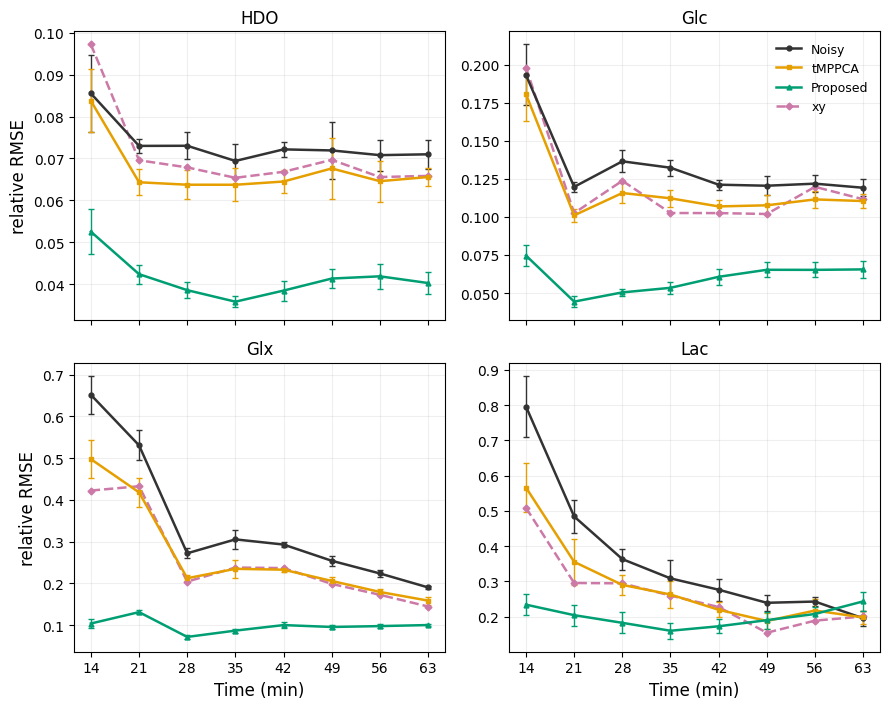

In [ ]:
# ---------- USER SETTINGS ----------
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

root = "MetabMaps"
gt_method = "Lesion_GT"
suffix = "Orig"

Noisy_Reps  = ["Lesion_noisy_1", "Lesion_noisy_2", "Lesion_noisy_3", "Lesion_noisy_4", "Lesion_noisy_5", "Lesion_noisy_6"]
Deep_Reps   = ["Lesion_deep_tmppca_1", "Lesion_deep_tmppca_2", "Lesion_deep_tmppca_3", "Lesion_deep_tmppca_4", "Lesion_deep_tmppca_5", "Lesion_deep_tmppca_6"]
tMPPCA_Reps = ["Lesion_tmppca_1", "Lesion_tmppca_2", "Lesion_tmppca_3", "Lesion_tmppca_4", "Lesion_tmppca_5", "Lesion_tmppca_6"]

# xy: single realization
xy_Reps = ["Lesion_tmppca_6"]

rep_methods = {
    "Noisy":    Noisy_Reps,
    "tMPPCA":   tMPPCA_Reps,
    "Proposed": Deep_Reps,
}
rep_methods_xy = {"xy": xy_Reps}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {
    "water": "HDO",
    "Glc":   "Glc",
    "Glx":   "Glx",
    "Lac":   "Lac",
}

time_axis = np.array([14, 21, 28, 35, 42, 49, 56, 63])

# -------------------- STYLE --------------------
DEFAULT_COLORS = {
    "noisy": "#333333",
    "tMPPCA_5D": "#E69F00",
    "deep_tMPPCA_5D": "#009E73",
    "xy": "#CC79A7",
}
DEFAULT_MARKERS = {
    "noisy": "o",
    "tMPPCA_5D": "s",
    "deep_tMPPCA_5D": "^",
    "xy": "D",          # ♦ marker for xy
}

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.grid": False,
})

LABEL_TO_SUFFIX = {
    "Noisy": "noisy",
    "tMPPCA": "tMPPCA_5D",
    "Proposed": "deep_tMPPCA_5D",
}

fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.2), sharex=True)
axes = axes.ravel()

lw, ms, cap, elw = 1.8, 3.5, 2, 1.0

# legend handles
legend_handles = [
    Line2D([0], [0],
           color=DEFAULT_COLORS[LABEL_TO_SUFFIX[k]],
           marker=DEFAULT_MARKERS[LABEL_TO_SUFFIX[k]],
           lw=lw, ms=ms, linestyle="-", label=k)
    for k in rep_methods.keys()
]
legend_handles.append(
    Line2D([0], [0],
           color=DEFAULT_COLORS["xy"],
           marker=DEFAULT_MARKERS["xy"],
           lw=lw, ms=ms,
           linestyle="--",
           label="xy")
)

for ax, (metab, mask) in zip(axes, metabs):

    curves = compute_mean_std_rrmse_time(
        root, metab, mask,
        gt_method=gt_method,
        rep_methods=rep_methods,
        suffix=suffix
    )

    x = time_axis

    for lab in rep_methods.keys():
        mean_t, std_t = curves[lab]
        suf = LABEL_TO_SUFFIX[lab]

        ax.errorbar(
            x, mean_t,
            yerr=std_t,
            color=DEFAULT_COLORS[suf],
            marker=DEFAULT_MARKERS[suf],
            linestyle="-",
            lw=lw, ms=ms,
            capsize=cap,
            elinewidth=elw,
        )

    # ---- xy curve: markers + dashed line, NO error bars ----
    curves_xy = compute_mean_std_rrmse_time(
        root, metab, mask,
        gt_method=gt_method,
        rep_methods=rep_methods_xy,
        suffix=suffix
    )
    xy_mean, _ = curves_xy["xy"]

    ax.plot(
        x, xy_mean,
        linestyle="--",
        marker=DEFAULT_MARKERS["xy"],
        color=DEFAULT_COLORS["xy"],
        lw=lw, ms=ms,
    )

    ax.set_title(DISPLAY_NAME.get(metab, metab))

    if ax in (axes[0], axes[2]):
        ax.set_ylabel("relative RMSE")

    ax.grid(True, alpha=0.2)
    ax.set_xticks(x)

axes[2].set_xlabel("Time (min)")
axes[3].set_xlabel("Time (min)")

axes[1].legend(handles=legend_handles, frameon=False, loc="upper right")

fig.tight_layout()
plt.savefig("rrmse_timecourse_2x2.pdf", bbox_inches="tight")
plt.show()
